# 🎓 Predicting Student Mental Health Score 

`Dataset`: Student_Social_Media_And_Mental_Health_Impact.csv — 5,000 students, 13 columns covering demographics (Age, Gender, Country), platform usage (Avg_Daily_Usage_Hours, Daily_Unlocks, Most_Used_Platform), lifestyle (Study_Hours, Sleep_Hours_Per_Night, Physical_Activity_Hours), and Stress_Level.

## Step 1. Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2. Load the Dataset

In [3]:
df = pd.read_csv('Student Social Media And Mental Health Impact.csv')

## Look at first 5 Rows
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [4]:
## Statistic of Dataset

df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


📌 `Reading this`: Most columns look reasonable — but look closely at Physical_Activity_Hours: the minimum value is -0.4. Negative hours aren't physically possible, so this is a data-entry glitch, not a real value. We will fix this in Data cleaning Step .

In [5]:
## Look at Data information 

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [6]:
## Check Nulls in Dataset 

df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

In [7]:
## check Duplicate  in Dataset 

df.duplicated().sum()

np.int64(2)

In [8]:
df.shape

(5000, 13)

## Step 4. Exploratory Data Analysis (EDA)

###  Distribution of the target (Mental_Health_Score)

<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

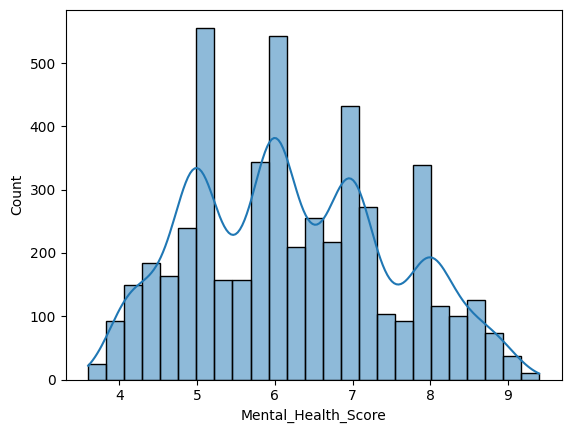

In [9]:
sns.histplot(df['Mental_Health_Score'], kde= True)

The Mental Health Score mostly Normaly Distributed 

###  Correlation heatmap

<Axes: >

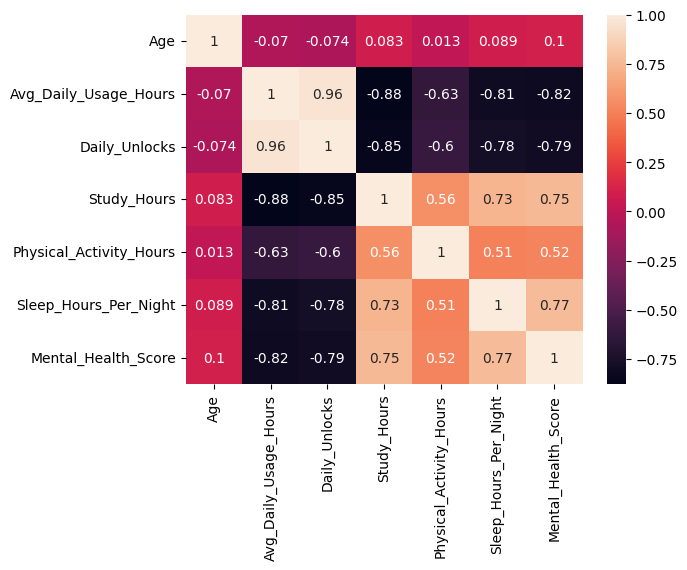

In [10]:
sns.heatmap(df.corr(numeric_only= True),annot= True)

### Stress Level vs Mental Health Score Relationship

In [11]:
df['Stress_Level'].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

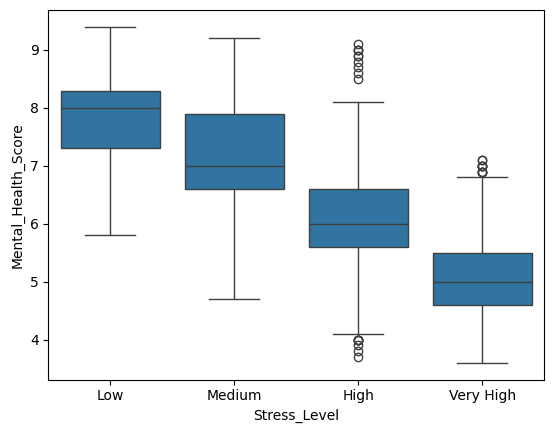

In [12]:
order = ['Low','Medium', 'High','Very High']

sns.boxplot( x ='Stress_Level', y= 'Mental_Health_Score' , order = order ,data= df)

More Mental Health means less Stress level

### Daily Usage Hours vs Mental Health Score

Does more time on social media relate to a lower score?

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

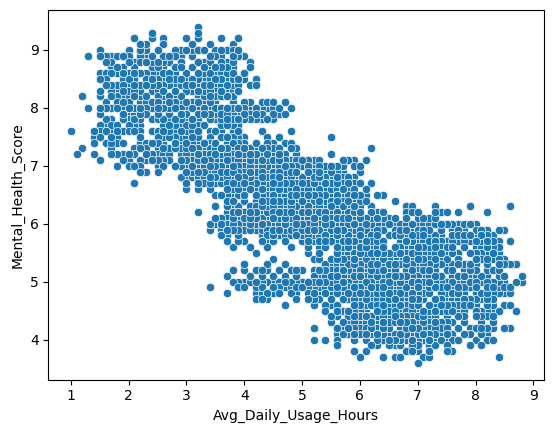

In [13]:
sns.scatterplot(x = 'Avg_Daily_Usage_Hours', y= 'Mental_Health_Score', data= df)

The Graph Clearly show -   More Daily Usage Hours - less Mental health
and less Daily Usage Hours - more  Mental health


<Axes: xlabel='Physical_Activity_Hours', ylabel='Mental_Health_Score'>

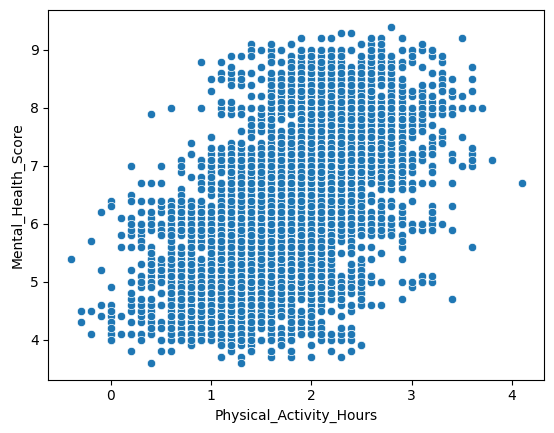

In [14]:
sns.scatterplot(x= 'Physical_Activity_Hours', y = 'Mental_Health_Score', data= df)

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

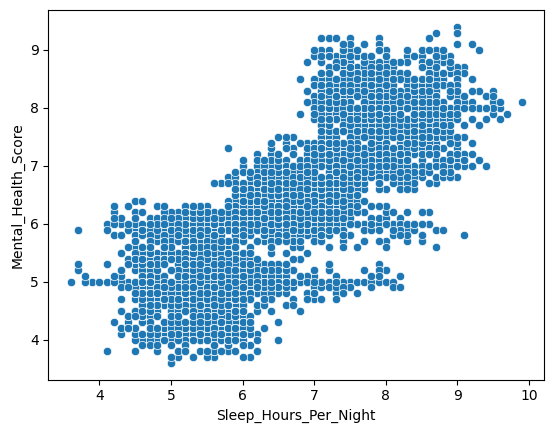

In [15]:
sns.scatterplot(x = 'Sleep_Hours_Per_Night', y = 'Mental_Health_Score', data= df)

<Axes: xlabel='Study_Hours', ylabel='Mental_Health_Score'>

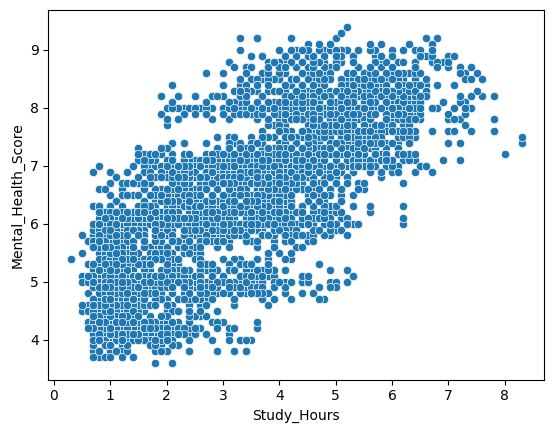

In [16]:
sns.scatterplot(x = 'Study_Hours', y = 'Mental_Health_Score', data= df)

### Most Used Platform (count)

A quick look at which platforms are most common in our dataset.

In [17]:
df['Most_Used_Platform'].value_counts()

Most_Used_Platform
Instagram    1130
TikTok        918
Facebook      719
LinkedIn      523
YouTube       491
Twitter       462
Snapchat      420
WhatsApp      175
LINE           50
VKontakte      40
KakaoTalk      36
WeChat         36
Name: count, dtype: int64

<Axes: xlabel='Most_Used_Platform', ylabel='count'>

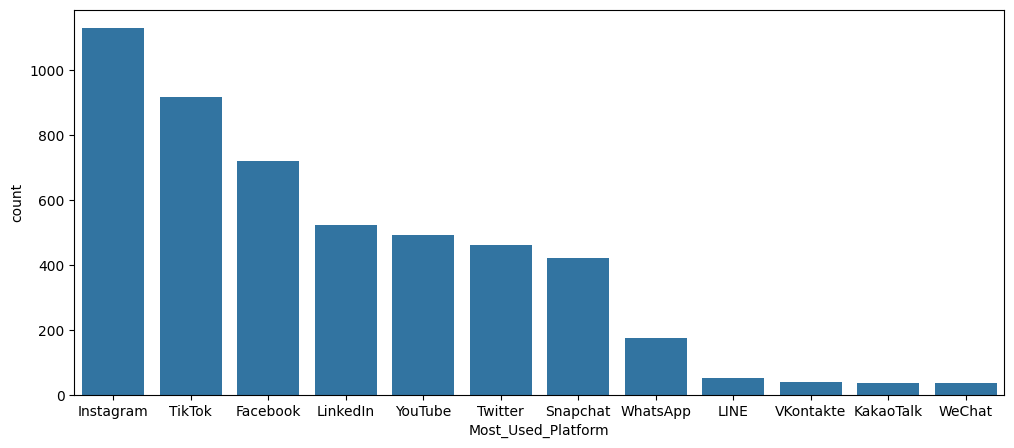

In [18]:
plt.figure(figsize=(12, 5)) 
sns.countplot(x= 'Most_Used_Platform', order= df['Most_Used_Platform'].value_counts().index, data= df)

### Checking Outliers

In [19]:
num_feature = df.select_dtypes(include= 'number')

Q1 = num_feature.quantile(0.25)
Q3 = num_feature.quantile(0.75)

IQR = Q3 - Q1
Lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

Outliers = (num_feature < Lower_bound )| (num_feature > upper_bound)
print(Outliers.sum())


Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


## Step 4. Data Cleaning

Two real issues to fix here — everything else in this dataset is already clean, so we don't manufacture cleaning steps that aren't needed.

In [20]:
df[df['Physical_Activity_Hours'] < 0]

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
2277,20,Male,Other,Undergraduate,Facebook,Networking,6.8,222,2.6,-0.1,4.7,Very High,4.6
2923,23,Female,USA,Graduate,Snapchat,Entertainment,7.9,223,1.1,-0.1,5.8,Very High,5.2
3056,19,Male,Other,Undergraduate,LinkedIn,Education,7.8,252,1.6,-0.3,5.7,Very High,4.3
3422,24,Male,Other,Graduate,Twitter,News,8.2,245,0.7,-0.1,5.8,Very High,4.4
3882,20,Female,Other,Undergraduate,YouTube,Education,5.5,207,2.2,-0.2,5.1,Very High,5.7
4058,21,Male,Other,Undergraduate,YouTube,Education,5.8,200,2.0,-0.1,7.4,High,6.2
4243,20,Female,Other,Undergraduate,YouTube,Education,5.6,207,2.6,-0.4,5.0,Very High,5.4
4406,20,Male,Other,Undergraduate,Facebook,Networking,7.2,222,2.6,-0.3,4.5,Very High,4.5
4522,19,Male,Other,Undergraduate,LinkedIn,Education,8.1,252,2.2,-0.2,5.7,Very High,4.1
4771,21,Male,India,Undergraduate,TikTok,Entertainment,7.6,222,1.0,-0.2,5.2,Very High,4.5


In [21]:
#1. Converting negative or unrealitstic value to realistic value 

df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].clip(lower = 0)

In [22]:
#2. drop Null Values

df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

In [23]:
#3. To Drop Duplicates 

df = df.drop_duplicates()

df.duplicated().sum()

np.int64(0)

## Step 6. Skewness

 near to 0 > Centralized (0.01, 0.002)

 negative > Left Skewed (-1.56)

 poistive (Toward 1) > Right Skewed (1.256)

In [ ]:
num_col = df.select_dtypes(include= 'number')
num_col.skew() 

Age                        0.155008
Avg_Daily_Usage_Hours      0.005575
Daily_Unlocks              0.002309
Study_Hours                0.436125
Physical_Activity_Hours    0.053288
Sleep_Hours_Per_Night      0.123919
Mental_Health_Score        0.207086
dtype: float64

<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

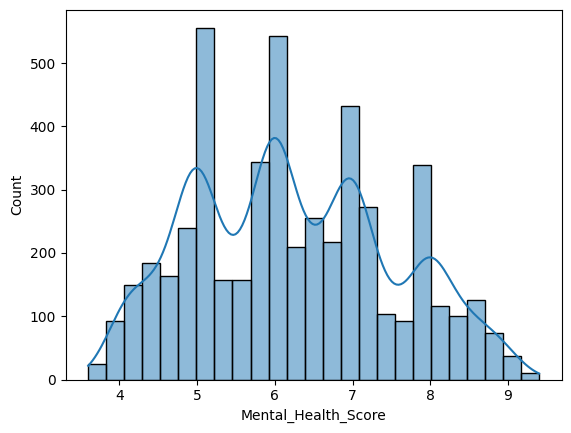

In [25]:
sns.histplot(df['Mental_Health_Score'], kde= True)

## Step 7. Feature Engineering

One meaningful engineered feature here: grouping Country.

Country has 111 unique values in this dataset — one-hot encoding that directly would add 110+ mostly-empty columns, which hurts the model far more than it helps (this is called high cardinality).

Dropping Country entirely throws away real signal — a student's country genuinely correlates with things like internet access, culture, and sleep norms.

The fix: keep the top 10 most frequent countries as their own category, and bucket everything else into "Other". We keep the signal that matters and lose the noise that doesn't.

In [26]:
Top_countries = df['Country'].value_counts().index[:10].tolist()

In [27]:
def Group_countries(Country):
    if Country in Top_countries:
        return Country
    else:
        return "Other"

In [28]:
df['Group_countries'] = df['Country'].apply(Group_countries)

In [29]:
df['Group_countries'].value_counts()

Group_countries
Other        3231
India         389
USA           354
Canada        230
Australia     198
UK            185
Germany       136
Mexico         94
Turkey         94
France         87
Name: count, dtype: int64

📌 Result: we went from 111 raw categories down to 11 manageable ones (10 countries + "Other"). 

## Step 8. Encoding Strategy

## Step 9: Train-Test Split

In [30]:
from sklearn.model_selection import train_test_split 

Skew_cols = ['Study_Hours']

numeric_cols = ['Age','Avg_Daily_Usage_Hours','Daily_Unlocks','Physical_Activity_Hours',
                    'Sleep_Hours_Per_Night']

Nominial_cols = ['Gender','Group_countries','Most_Used_Platform','Purpose_Of_Use']

Ordinal_cols = ['Academic_Level','Stress_Level'] 

feature_cols = Skew_cols + numeric_cols + Nominial_cols + Ordinal_cols

x = df[feature_cols]

y = df['Mental_Health_Score']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size= 0.30 , random_state= 42)

## Step 10. Preprocessing using ColumnTransformer

Our columns need different treatment:

Study_Hours (the skewed one) → impute → log1p transform → scale

The other numeric columns → impute → scale (no skew to fix)

Stress_Level, Academic_Level → impute → OrdinalEncoder with an explicit order

The nominal columns → impute → OneHotEncoder

In [31]:
df['Academic_Level'].value_counts()

Academic_Level
Undergraduate    3630
Graduate          918
High School       450
Name: count, dtype: int64

In [32]:
df['Stress_Level'].value_counts()

Stress_Level
Very High    1621
High         1439
Medium       1295
Low           643
Name: count, dtype: int64

In [33]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

#1. skewed feature
skew_pipeline = Pipeline(steps=[
        ('log_transformer',FunctionTransformer(np.log1p)),
        ('scaler',StandardScaler())
])

#2. Numerical feature
numeric_pipeline= Pipeline(steps=[
    ('scale',StandardScaler())
])

#3. Ordinal feature
education_order = ['High School', 'Undergraduate', 'Graduate']
income_order = ['Low', 'Medium', 'High', 'Very High']

ordinal_pipeline = Pipeline(steps=[
    ('encode',OrdinalEncoder(categories=[education_order,income_order]))
])

#4. Nominal feature
nominal_pipeline = Pipeline(steps=[
    ('encode',OneHotEncoder(handle_unknown='ignore'))
])

# Column Transformer
preprocessor = ColumnTransformer(transformers=[
    ('skew_pipeline',skew_pipeline,Skew_cols),
    ('numeric',numeric_pipeline,numeric_cols),
    ('ordinal',ordinal_pipeline,Ordinal_cols),
    ('nominal',nominal_pipeline,Nominial_cols)
])

## Step 11: Build a Pipeline

## Step 12: Model Building

###  Baseline: Linear Regression

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error 
from  sklearn.model_selection import cross_val_score

lr_pipeline = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('regressor',LinearRegression())
])

lr_pipeline.fit(x_train,y_train)

lr_pred       = lr_pipeline.predict(x_test)
lr_pred_train = lr_pipeline.predict(x_train)

lr_r2_test     = r2_score(y_test,lr_pred)
lr_r2_train     = r2_score(y_train,lr_pred_train)
lr_mae          = mean_absolute_error(y_test,lr_pred)

score = cross_val_score(
        lr_pipeline,
        x,
        y,
        cv=5,
        scoring= 'r2'
)


print('\nAccuracy of Training:\n',lr_r2_train)
print('\nAccuracy of Test\n:',lr_r2_test)
print('\nAccuracy score after cross validation:\n',score.mean())
print('\nMean Absulute Error:\n',lr_mae)



Accuracy of Training:
 0.7235887539429784

Accuracy of Test
: 0.7398830040607447

Accuracy score after cross validation:
 0.7213740292818562

Mean Absulute Error:
 0.5365354684747639


### Random Forest (default settings)

Same preprocessor, different model at the end — that's the entire point of building the pipeline once.

In [35]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score


Rf_pipeline = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('random forest',RandomForestRegressor(random_state= 42))
])

Rf_pipeline.fit(x_train, y_train)
rf_preds          = Rf_pipeline.predict(x_test)
rf_preds_training = Rf_pipeline.predict(x_train)

rf_r2_testing  = r2_score(y_test, rf_preds)
rf_r2_training = r2_score(y_train, rf_preds_training)
rf_mae         = mean_absolute_error(y_test, rf_preds)

score = cross_val_score(
        Rf_pipeline,
        x,
        y,
        cv=5,
        scoring= 'r2'
)


print(f"Accuracy of Training: {rf_r2_training}")
print(f"Accuracy of Testing: {rf_r2_testing}")
print('Accuracy score after cross validation:',score.mean())
print(f"MAE : {rf_mae}")

Accuracy of Training: 0.9807391470256103
Accuracy of Testing: 0.8773197780742487
Accuracy score after cross validation: 0.8843779819657026
MAE : 0.3466800333333334


## Step 14: Save the Model

In [36]:
import joblib
joblib.dump(Rf_pipeline,'Student_Mental_health.pkl')



['Student_Mental_health.pkl']